In [23]:
import confnotebook

In [24]:
from pathlib import Path

source = Path("../examples/test/full")

files = sorted(source.glob("*.pdf"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")

[0] 10
[1] 126164
[2] 14964427_Енисейская ТГК-13-БРАЗ
[3] 14976087_АвеларСолар Тех-БРАЗ-1
[4] 15120979_Форвард Энерго-БРАЗ-1
[5] 15235008_ОГК-2-БРАЗ-1
[6] 25
[7] 33
[8] 4
[9] 44
[10] 7-1
[11] АС ВНИИМ Менделеева Д.И. - БРАЗ на 31.12.24
[12] АС ВНИИМ Менделеева Д.И. - РУ на 31.12.24
[13] АС КРЕЗОЛ-САЗ на 31.08.25
[14] АС Охрана Металлург-САЗ на 31.12.25
[15] АС РУ- ВОСЬМОЙ ВЕТРОПАРК
[16] АС Фрейт Линк-БРАЗ на 30.09.25
[17] АСР СДД 2 кв.2024 (подп. к-а)
[18] Акт сверки взаимных расчетов №00000379931 от 30.04.2024
[19] Акт сверки №0000
[20] Акт сверки №MOW00-0087974   от 10.06.2024
[21] Акт сверки №ТРБП-000006 от 10.01.2024
[22] Браз-Юнигрин Пауэр
[23] ЕВР-НКАЗ
[24] Неформализованный_первичный_документ_23_ИИА_03_00342_от_31_03
[25] Неформализованный_первичный_документ_23_ИИА_03_02596_от_31_03
[26] Неформализованный_первичный_документ_23_ИИА_03_03623_от_31_03
[27] Неформализованный_первичный_документ_23_ИИА_06_01794_от_30_06
[28] ПР_АС КРЕЗОЛ-САЗ на 31.08.25
[29] ПР_АС Фрейт Линк-

In [25]:
IDX_FILE = 2

In [26]:
from vision_core.debug_image_observer import DebugImageObserver

file = files[IDX_FILE]
output_dir = f"../examples/output/{file.stem}"

debug_image_observer = DebugImageObserver(output_dir=output_dir)

In [27]:
from vision_core.loader.pdf_loader import PDFLoader

img = PDFLoader(pdf_bytes=file.read_bytes()).get_page_image(page_num=0, dpi=200)

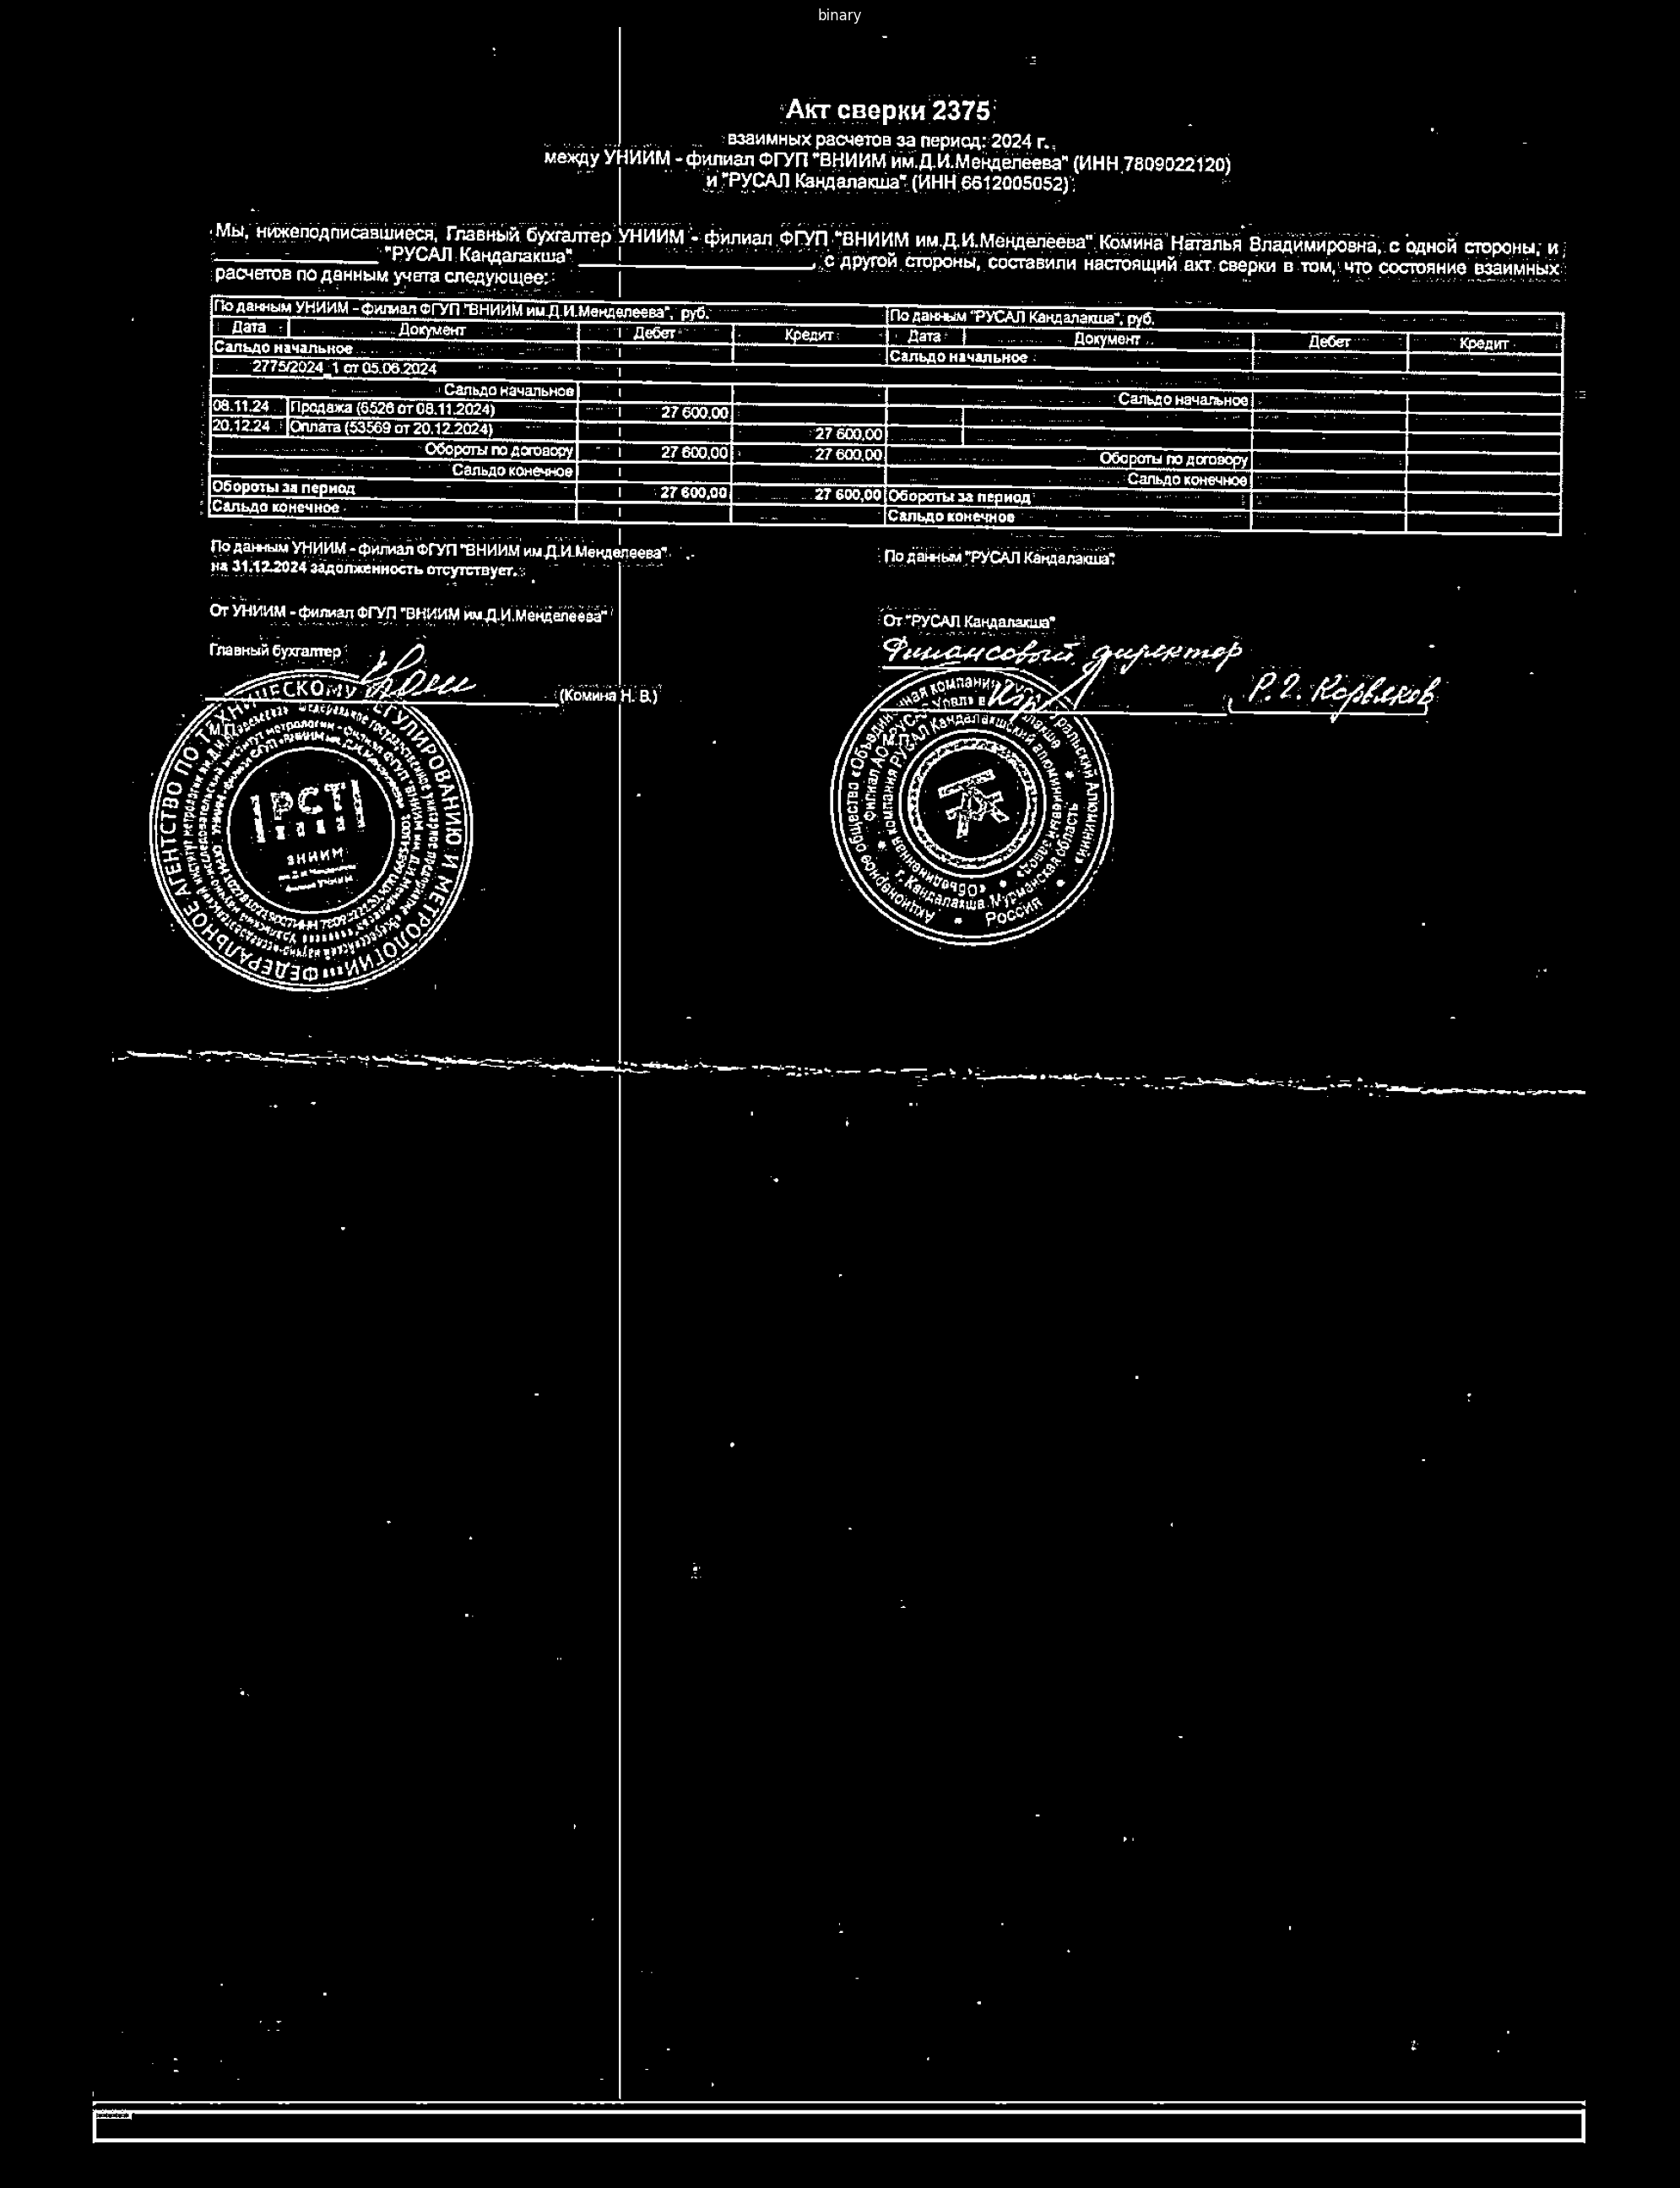

In [28]:
import cv2
import matplotlib.pyplot as plt

# detected lines
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (1, 1), 0)
binary = cv2.adaptiveThreshold(~blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 9, -3)


plt.figure(figsize=(20, 30))
plt.imshow(binary, cmap='gray')
plt.title("binary")
plt.axis("off")
plt.tight_layout()
plt.show()

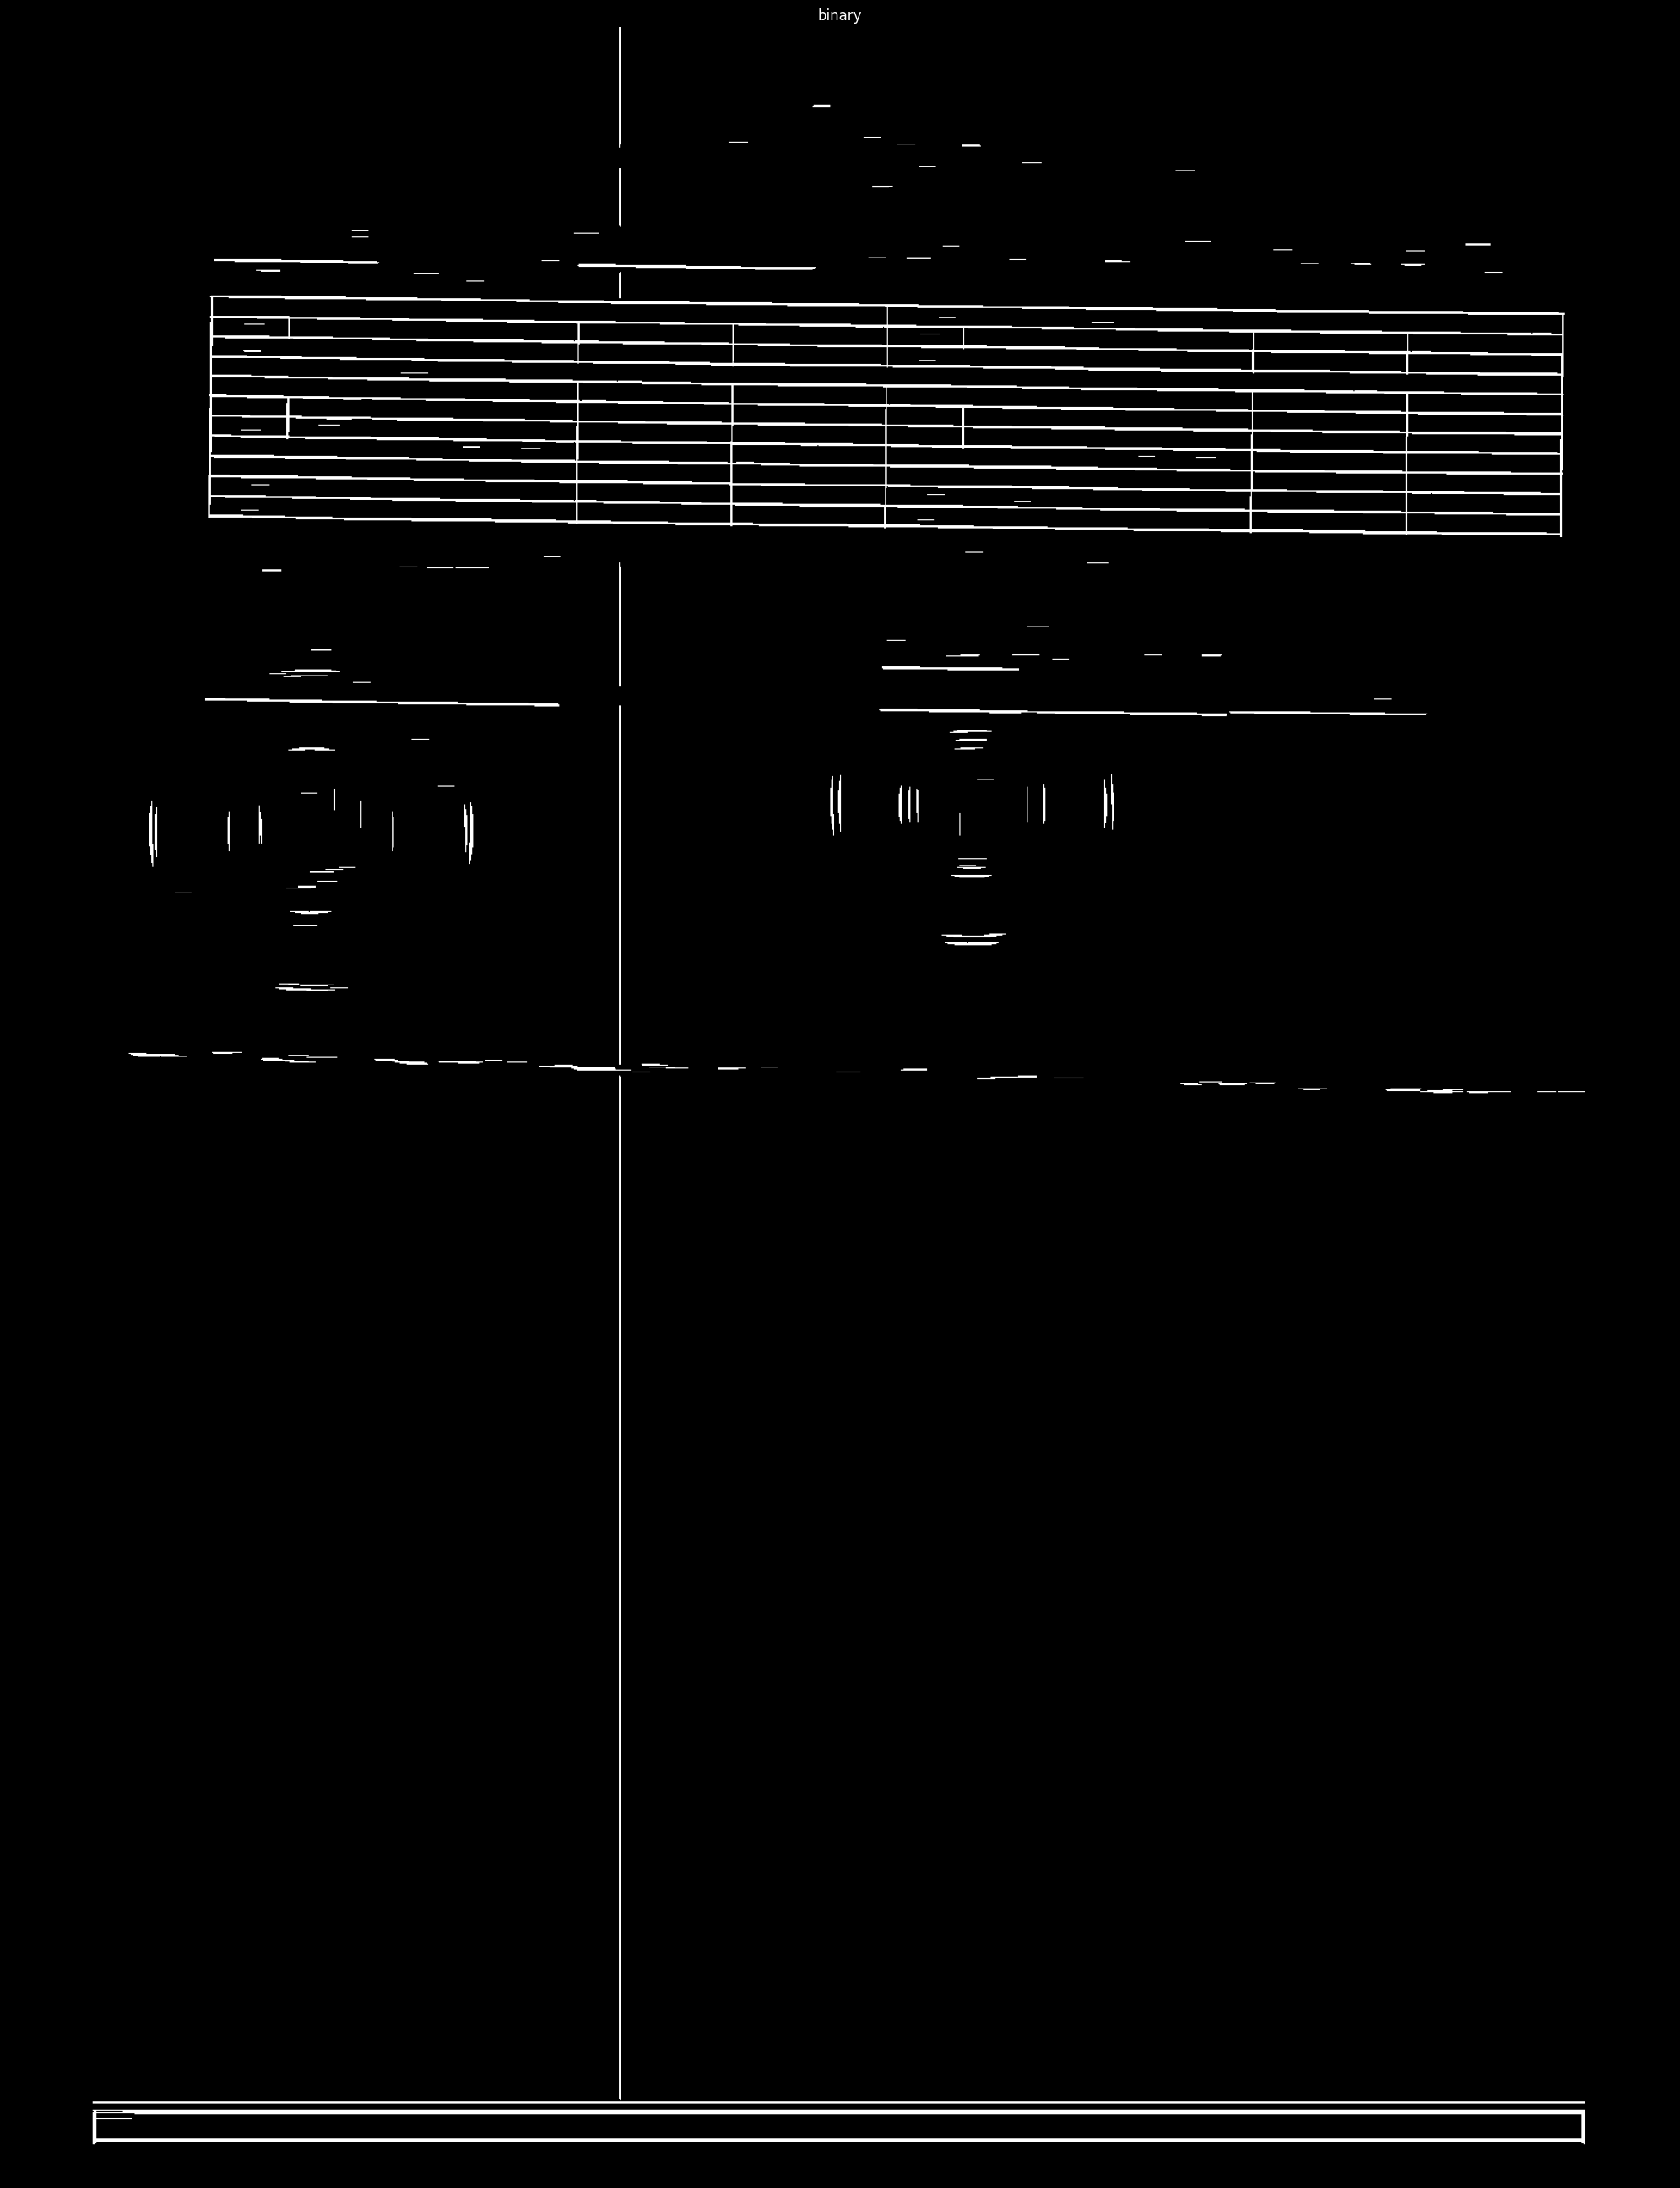

In [29]:
h_img = binary.copy()
v_img = binary.copy()
scale = 100

h_size = int(h_img.shape[1]/scale)
h_structure = cv2.getStructuringElement(cv2.MORPH_RECT,(h_size,1))

h_erode_img = cv2.erode(h_img,h_structure, 2)
h_dilate_img = cv2.dilate(h_erode_img,h_structure, 2)

v_size = int(v_img.shape[0] / scale)
v_structure = cv2.getStructuringElement(cv2.MORPH_RECT, (1, v_size))

v_erode_img = cv2.erode(v_img, v_structure, 2)
v_dilate_img = cv2.dilate(v_erode_img, v_structure, 2)



plt.figure(figsize=(20, 30))
plt.imshow(v_dilate_img + h_dilate_img, cmap='gray')
plt.title("binary")
plt.axis("off")
plt.tight_layout()
plt.show()

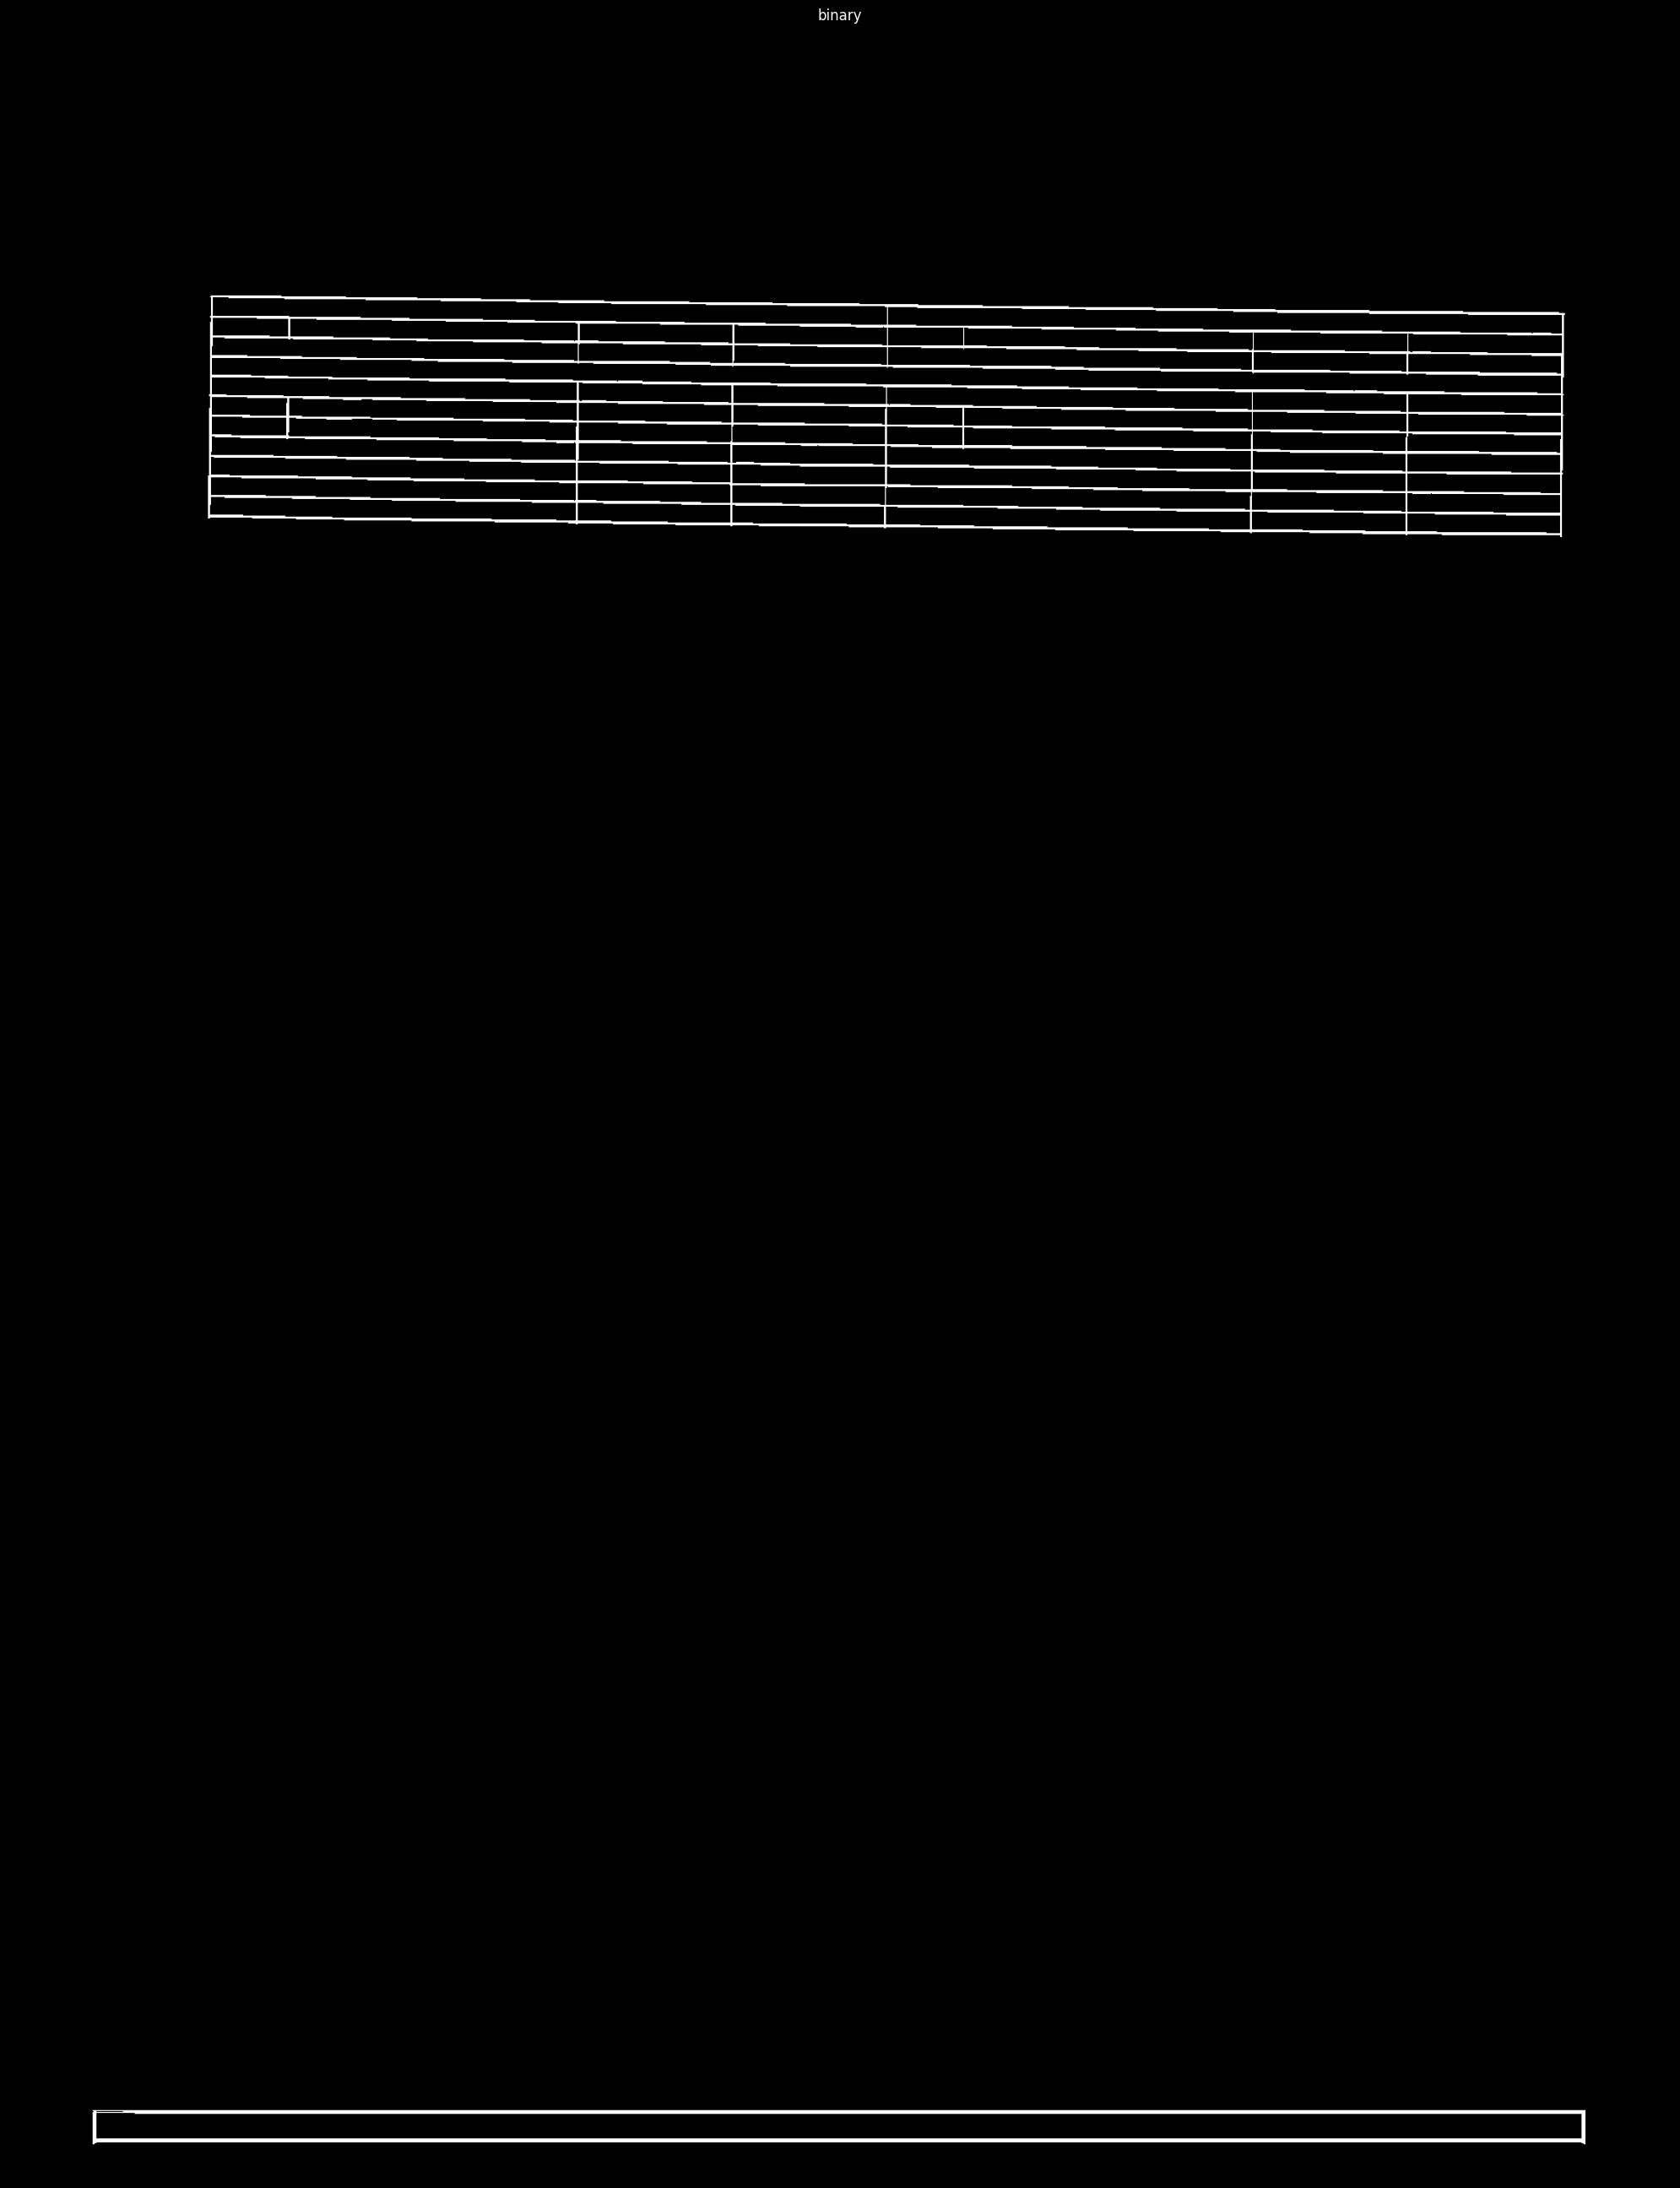

In [30]:
from vision_core.preprocessor.table_preprocessor import TablePreprocessor

tp = TablePreprocessor()

intersec = cv2.bitwise_and(h_dilate_img, v_dilate_img)

h_mask = tp._clean_mask(h_dilate_img, intersec)
v_mask = tp._clean_mask(v_dilate_img, intersec, 20, type = "vertical")

plt.figure(figsize=(20, 30))
plt.imshow(h_mask + v_mask, cmap='gray')
plt.title("binary")
plt.axis("off")
plt.tight_layout()
plt.show()